<a href="https://colab.research.google.com/github/marcelo7bastos/relatorio_dados_damei/blob/main/pronaf_evolucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Insiando o programa

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import os
import glob

Carregando os dados

In [12]:
# Diretórios principais
RAW_DIR = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_historico/PRONAF'
ARQUIVO_ATUAL = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/dado_atual/pronaf_gaia_20260414_teste.xlsx'
OUTPUT_DIR = '/content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_teste'

# Garante que a pasta de saída exista
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Carregar os dados históricos da pasta
excel_files = glob.glob(os.path.join(RAW_DIR, '*.xlsx'))
excel_files.sort() # Adicionado para garantir a ordem cronológica (2019, 2020, etc.)

print(f'Foram encontrados {len(excel_files)} arquivos:')

# Dicionário para armazenar os DataFrames
bases_pronaf = {}

for f in excel_files:
    nome_arquivo = os.path.basename(f)
    print(f'  • Carregando aba "Dados" de: {nome_arquivo}')

    # Carrega APENAS a aba 'Dados' de cada arquivo
    bases_pronaf[nome_arquivo] = pd.read_excel(f, sheet_name='Dados')

print('\nConcluído! Todos os dados foram carregados na variável "bases_pronaf".')


# 2. Carregar o arquivo específico com o dado atual
nome_arquivo_atual = os.path.basename(ARQUIVO_ATUAL)
print(f'\nCarregando a base atual: {nome_arquivo_atual}')

# Carrega o arquivo atual na mesma variável (assumindo que ele também tenha a aba 'Dados')
bases_pronaf[nome_arquivo_atual] = pd.read_excel(ARQUIVO_ATUAL, sheet_name='Dados')

print(f'\nConcluído! Um total de {len(bases_pronaf)} arquivos (histórico + atual) foram carregados na variável "bases_pronaf".')

Foram encontrados 11 arquivos:
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2015.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2016.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2017.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2018.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2019.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2020.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2021.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2022.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2023.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2024.xlsx
  • Carregando aba "Dados" de: pronaf_gaia_historico_anual_2025.xlsx

Concluído! Todos os dados foram carregados na variável "bases_pronaf".

Carregando a base atual: pronaf_gaia_20260414_teste.xlsx

Concluído! Um total de 12 arquivos (histórico + atual) foram carregados na vari

In [13]:
#Comparando as colunas

arquivos_carregados = list(bases_pronaf.keys())
arquivo_referencia = arquivos_carregados[0]
colunas_referencia = set(bases_pronaf[arquivo_referencia].columns)

print(f"Usando '{arquivo_referencia}' como padrão ({len(colunas_referencia)} colunas).")
print("-" * 50)

todas_iguais = True

# Compara os demais arquivos com o arquivo de referência
for arquivo in arquivos_carregados[1:]:
    colunas_atuais = set(bases_pronaf[arquivo].columns)

    if colunas_referencia == colunas_atuais:
        print(f"✅ {arquivo} -> OK (Mesmas colunas)")
    else:
        todas_iguais = False
        print(f"❌ {arquivo} -> DIFERENÇA ENCONTRADA")

        # O que tem na referência mas falta neste arquivo
        colunas_faltando = colunas_referencia - colunas_atuais
        if colunas_faltando:
            print(f"    ⚠️ Faltando: {colunas_faltando}")

        # O que tem neste arquivo mas não tem na referência
        colunas_sobrando = colunas_atuais - colunas_referencia
        if colunas_sobrando:
            print(f"    ➕ Sobrando/A mais: {colunas_sobrando}")

print("-" * 50)
if todas_iguais:
    print("Sucesso! Todos os arquivos possuem exatamente as mesmas colunas. Estão prontos para serem unidos.")
else:
    print("Atenção: Foram encontradas diferenças nas colunas (veja o log acima).")

Usando 'pronaf_gaia_historico_anual_2015.xlsx' como padrão (19 colunas).
--------------------------------------------------
✅ pronaf_gaia_historico_anual_2016.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2017.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2018.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2019.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2020.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2021.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2022.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2023.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2024.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_historico_anual_2025.xlsx -> OK (Mesmas colunas)
✅ pronaf_gaia_20260414_teste.xlsx -> OK (Mesmas colunas)
--------------------------------------------------
Sucesso! Todos os arquivos possuem exatamente as mesmas colunas. Estão prontos para serem unidos.


In [14]:
#Agrupando todas as tabelas em um único dataframa
#Lista para guardar os DataFrames temporários
lista_dfs = []

# Percorre o dicionário adicionando a coluna de origem
for nome_arquivo, df in bases_pronaf.items():
    df_temp = df.copy() # Cria uma cópia para não alterar o dicionário original
    df_temp['arquivo_origem'] = nome_arquivo # Adiciona a rastreabilidade
    lista_dfs.append(df_temp)

# Junta (empilha) todos os DataFrames em um único
df_pronaf_consolidado = pd.concat(lista_dfs, ignore_index=True)

print("✅ Bases consolidadas com sucesso!")
print(f"Total de linhas: {df_pronaf_consolidado.shape[0]}")
print(f"Total de colunas: {df_pronaf_consolidado.shape[1]}")
print("-" * 50)

# Mostra as 5 primeiras linhas para você inspecionar visualmente
display(df_pronaf_consolidado.head())

✅ Bases consolidadas com sucesso!
Total de linhas: 63868
Total de colunas: 20
--------------------------------------------------


,dt_referencia,dt_geracao,ANO,nome_municipio,uf,cod_ibge_municipio,cod_ibge_uf,qtd_contratos_anual_Feminino,qtd_contratos_anual_Masculino,qtd_contratos_anual_Sem_Identificacao,valor_total_contratos_anual_Feminino,valor_total_contratos_anual_Masculino,valor_total_contratos_anual_Sem_Identificacao,qtd_operacoes_anual_Feminino,qtd_operacoes_anual_Masculino,qtd_operacoes_anual_Sem_Identificacao,ticket_medio_anual_Feminino,ticket_medio_anual_Masculino,ticket_medio_anual_Sem_Identificacao,arquivo_origem
0,2015_12,2026_04_29,2015,Acrelândia,AC,1200013,12,79,260,0,1809742.00,7032661.40,0.0,79,260,0,22908.126582,27048.697692,0.0,pronaf_gaia_historico_anual_2015.xlsx
1,2015_12,2026_04_29,2015,Assis Brasil,AC,1200054,12,3,0,0,51998.85,0.00,0.0,3,0,0,17332.950000,0.000000,0.0,pronaf_gaia_historico_anual_2015.xlsx
2,2015_12,2026_04_29,2015,Brasiléia,AC,1200104,12,45,89,0,889395.49,2660606.24,0.0,45,89,0,19764.344222,29894.452135,0.0,pronaf_gaia_historico_anual_2015.xlsx
3,2015_12,2026_04_29,2015,Bujari,AC,1200138,12,8,29,0,315031.28,788523.79,0.0,8,29,0,39378.910000,27190.475517,0.0,pronaf_gaia_historico_anual_2015.xlsx
4,2015_12,2026_04_29,2015,Capixaba,AC,1200179,12,14,8,0,349557.39,136963.52,0.0,14,8,0,24968.385000,17120.440000,0.0,pronaf_gaia_historico_anual_2015.xlsx


In [15]:
df_pronaf_consolidado.columns.tolist()

['dt_referencia',
 'dt_geracao',
 'ANO',
 'nome_municipio',
 'uf',
 'cod_ibge_municipio',
 'cod_ibge_uf',
 'qtd_contratos_anual_Feminino',
 'qtd_contratos_anual_Masculino',
 'qtd_contratos_anual_Sem_Identificacao',
 'valor_total_contratos_anual_Feminino',
 'valor_total_contratos_anual_Masculino',
 'valor_total_contratos_anual_Sem_Identificacao',
 'qtd_operacoes_anual_Feminino',
 'qtd_operacoes_anual_Masculino',
 'qtd_operacoes_anual_Sem_Identificacao',
 'ticket_medio_anual_Feminino',
 'ticket_medio_anual_Masculino',
 'ticket_medio_anual_Sem_Identificacao',
 'arquivo_origem']

In [17]:
#Tratamento dos dados


# 1. Definir as listas de colunas
colunas_texto = [
    'dt_referencia', 'dt_geracao', 'ANO', 'nome_municipio',
    'uf', 'cod_ibge_municipio', 'cod_ibge_uf', 'arquivo_origem'
]

colunas_numero = [
    'qtd_contratos_anual_Feminino', 'qtd_contratos_anual_Masculino', 'qtd_contratos_anual_Sem_Identificacao',
    'valor_total_contratos_anual_Feminino', 'valor_total_contratos_anual_Masculino', 'valor_total_contratos_anual_Sem_Identificacao',
    'qtd_operacoes_anual_Feminino', 'qtd_operacoes_anual_Masculino', 'qtd_operacoes_anual_Sem_Identificacao',
    'ticket_medio_anual_Feminino', 'ticket_medio_anual_Masculino', 'ticket_medio_anual_Sem_Identificacao'
]

print("A iniciar o tratamento dos dados...")

# 2. Tratamento das colunas de texto (Converter para texto e remover espaços)
for col in colunas_texto:
    if col in df_pronaf_consolidado.columns:
        # Converte para string e remove espaços em branco nas extremidades (strip)
        df_pronaf_consolidado[col] = df_pronaf_consolidado[col].astype(str).str.strip()

        # Nota: Caso queira remover *absolutamente todos* os espaços (mesmo entre as palavras),
        # substitua a linha acima por:
        # df_pronaf_consolidado[col] = df_pronaf_consolidado[col].astype(str).str.replace(' ', '', regex=False)

# 3. Tratamento das colunas numéricas (Definir como número)
for col in colunas_numero:
    if col in df_pronaf_consolidado.columns:
        # pd.to_numeric converte de forma segura.
        # errors='coerce' transforma eventuais textos com erro (ex: '-') em valores nulos (NaN), permitindo fazer contas depois
        df_pronaf_consolidado[col] = pd.to_numeric(df_pronaf_consolidado[col], errors='coerce')

print("Tratamento concluído com sucesso!\n")
print("-" * 50)
print("Resumo dos tipos de dados atualizados:")
# Exibe um resumo para confirmar se os tipos estão corretos (object/string e float/int)
print(df_pronaf_consolidado[colunas_texto + colunas_numero].dtypes)

A iniciar o tratamento dos dados...
Tratamento concluído com sucesso!

--------------------------------------------------
Resumo dos tipos de dados atualizados:
dt_referencia                                     object
dt_geracao                                        object
ANO                                               object
nome_municipio                                    object
uf                                                object
cod_ibge_municipio                                object
cod_ibge_uf                                       object
arquivo_origem                                    object
qtd_contratos_anual_Feminino                       int64
qtd_contratos_anual_Masculino                      int64
qtd_contratos_anual_Sem_Identificacao              int64
valor_total_contratos_anual_Feminino             float64
valor_total_contratos_anual_Masculino            float64
valor_total_contratos_anual_Sem_Identificacao    float64
qtd_operacoes_anual_Feminino             

Teste de graficos

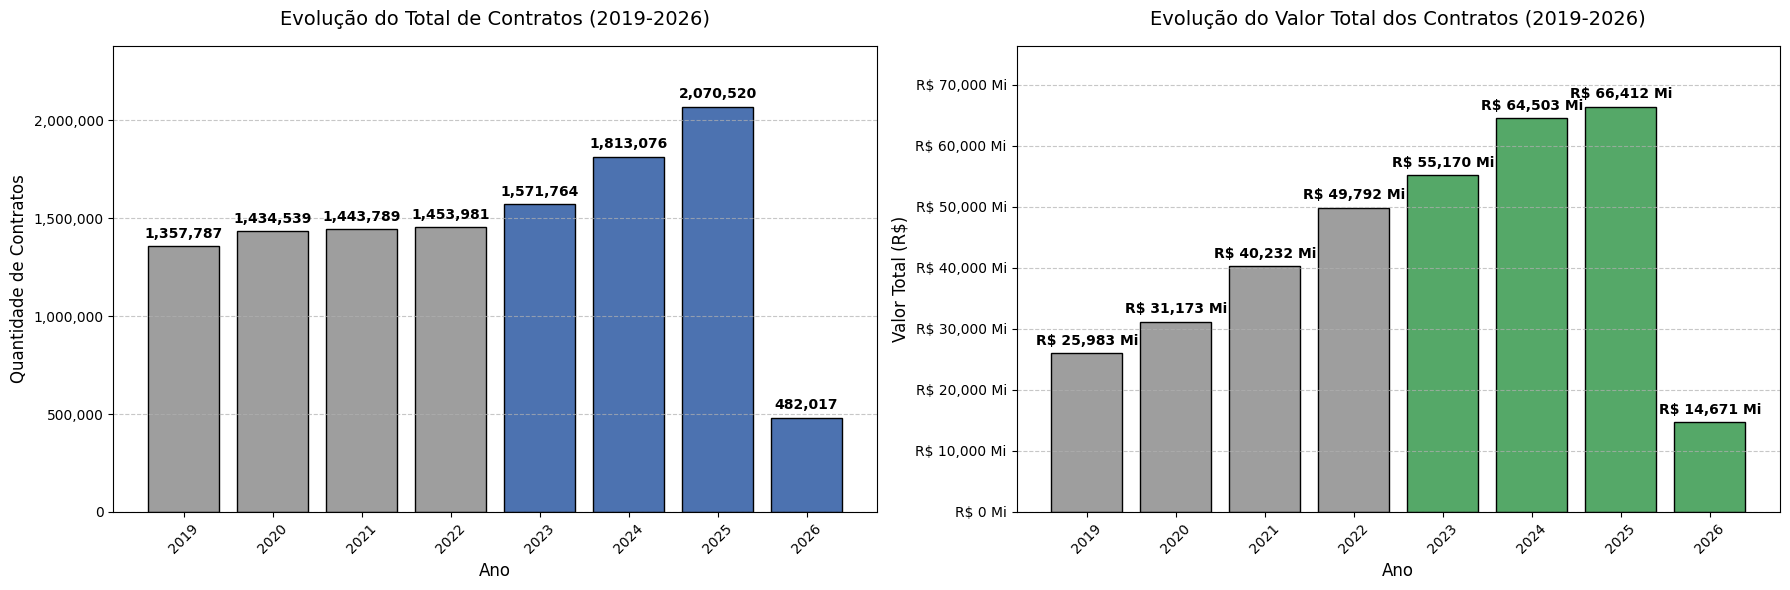

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. Criar colunas de Totais Globais
df_pronaf_consolidado['qtd_contratos_total'] = (
    df_pronaf_consolidado['qtd_contratos_anual_Feminino'].fillna(0) +
    df_pronaf_consolidado['qtd_contratos_anual_Masculino'].fillna(0) +
    df_pronaf_consolidado['qtd_contratos_anual_Sem_Identificacao'].fillna(0)
)

df_pronaf_consolidado['valor_contratos_total'] = (
    df_pronaf_consolidado['valor_total_contratos_anual_Feminino'].fillna(0) +
    df_pronaf_consolidado['valor_total_contratos_anual_Masculino'].fillna(0) +
    df_pronaf_consolidado['valor_total_contratos_anual_Sem_Identificacao'].fillna(0)
)

# 2. FILTRAR OS ANOS DE 2019 A 2026
# Converte a coluna ANO para numérico para facilitar o filtro matemático
df_pronaf_consolidado['ANO_num'] = pd.to_numeric(df_pronaf_consolidado['ANO'], errors='coerce')

# Aplica o filtro desejado
df_filtrado = df_pronaf_consolidado[
    (df_pronaf_consolidado['ANO_num'] >= 2019) &
    (df_pronaf_consolidado['ANO_num'] <= 2026)
].copy()

# 3. Agrupar os dados por Ano (usando a base filtrada)
df_evolucao = df_filtrado.groupby('ANO_num')[['qtd_contratos_total', 'valor_contratos_total']].sum().reset_index()

# Garantir que o ano fique sem casas decimais (ex: 2019 em vez de 2019.0) e ordenado
df_evolucao['ANO_num'] = df_evolucao['ANO_num'].astype(int)
df_evolucao = df_evolucao.sort_values('ANO_num')

# 4. Definir cores dinâmicas
# Cria uma lista de cores: Cinza para anos <= 2022, e as cores originais para os mais recentes
cores_qtd = ['#9E9E9E' if ano <= 2022 else '#4C72B0' for ano in df_evolucao['ANO_num']]
cores_valor = ['#9E9E9E' if ano <= 2022 else '#55A868' for ano in df_evolucao['ANO_num']]

# 5. Desenhar os Gráficos
# Apenas UMA chamada para criar a figura com 2 gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

## ----- Gráficos -------

# --- Gráfico 1: Quantidade de Contratos ---
# Passamos a lista 'cores_qtd' e guardamos as barras na variável 'barras_qtd'
barras_qtd = ax1.bar(df_evolucao['ANO_num'].astype(str), df_evolucao['qtd_contratos_total'], color=cores_qtd, edgecolor='black')
ax1.set_title('Evolução do Total de Contratos (2019-2026)', fontsize=14, pad=15)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Quantidade de Contratos', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar o valor no topo de cada barra (Quantidade)
for barra in barras_qtd:
    altura = barra.get_height()
    ax1.annotate(f'{int(altura):,}', # Formata com separador de milhar
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 4),  # Desloca o texto 4 pontos para cima
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Gráfico 2: Valor Total dos Contratos ---
# Passamos a lista 'cores_valor' e guardamos as barras na variável 'barras_valor'
barras_valor = ax2.bar(df_evolucao['ANO_num'].astype(str), df_evolucao['valor_contratos_total'], color=cores_valor, edgecolor='black')
ax2.set_title('Evolução do Valor Total dos Contratos (2019-2026)', fontsize=14, pad=15)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Valor Total (R$)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x/1e6:,.0f} Mi'))
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar o valor no topo de cada barra (Valor)
for barra in barras_valor:
    altura = barra.get_height()
    # Formata em milhões para não poluir visualmente (ex: R$ 150 Mi)
    rotulo = f'R$ {altura/1e6:,.0f} Mi'
    ax2.annotate(rotulo,
                 xy=(barra.get_x() + barra.get_width() / 2, altura),
                 xytext=(0, 4),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Aumentar um pouco o limite do eixo Y para o texto não encostar no teto do gráfico
ax1.set_ylim(0, df_evolucao['qtd_contratos_total'].max() * 1.15)
ax2.set_ylim(0, df_evolucao['valor_contratos_total'].max() * 1.15)

plt.tight_layout()
plt.show()

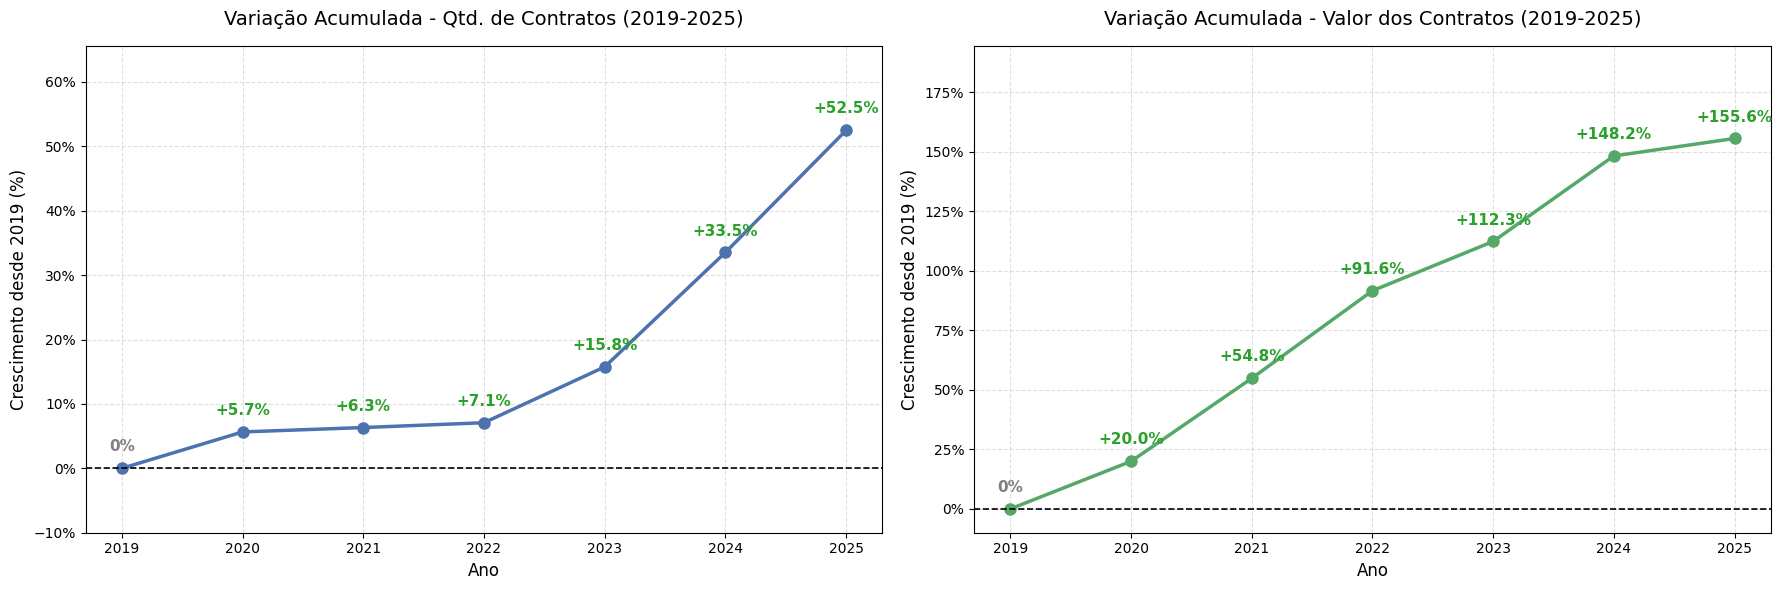

In [38]:
# Gráfico de variação acumulada

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. Aplicar o filtro estrito (2019 a 2025) e agrupar
df_filtrado_25 = df_pronaf_consolidado[
    (df_pronaf_consolidado['ANO_num'] >= 2019) &
    (df_pronaf_consolidado['ANO_num'] <= 2025)
].copy()

df_evolucao_25 = df_filtrado_25.groupby('ANO_num')[['qtd_contratos_total', 'valor_contratos_total']].sum().reset_index()
df_evolucao_25['ANO_num'] = df_evolucao_25['ANO_num'].astype(int)
df_evolucao_25 = df_evolucao_25.sort_values('ANO_num')

# 2. Calcular a variação ACUMULADA em relação ao ano-base (2019)
base_qtd = df_evolucao_25.loc[df_evolucao_25['ANO_num'] == 2019, 'qtd_contratos_total'].values[0]
base_valor = df_evolucao_25.loc[df_evolucao_25['ANO_num'] == 2019, 'valor_contratos_total'].values[0]

# Fórmula da variação acumulada: ((Valor_do_Ano / Valor_da_Base) - 1) * 100
df_evolucao_25['var_acum_qtd'] = ((df_evolucao_25['qtd_contratos_total'] / base_qtd) - 1) * 100
df_evolucao_25['var_acum_valor'] = ((df_evolucao_25['valor_contratos_total'] / base_valor) - 1) * 100

# 3. Desenhar os Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

## ----- Gráfico 1: Variação Acumulada da Quantidade -------
ax1.plot(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_qtd'], color='#4C72B0', marker='o', linewidth=2.5, markersize=8)
ax1.set_title('Variação Acumulada - Qtd. de Contratos (2019-2025)', fontsize=14, pad=15)
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Crescimento desde 2019 (%)', fontsize=12)
ax1.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax1.grid(axis='both', linestyle='--', alpha=0.4)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Adicionar os rótulos de dados
for x, y in zip(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_qtd']):
    deslocamento = 10 if y >= 0 else -18
    alinhamento_v = 'bottom' if y >= 0 else 'top'
    cor_texto = '#2CA02C' if y > 0 else ('#D62728' if y < 0 else '#7F7F7F')
    texto = '0%' if x == '2019' else f'{y:+.1f}%'
    ax1.annotate(texto, xy=(x, y), xytext=(0, deslocamento), textcoords="offset points", ha='center', va=alinhamento_v, fontsize=11, fontweight='bold', color=cor_texto)

## ----- Gráfico 2: Variação Acumulada do Valor -------
ax2.plot(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_valor'], color='#55A868', marker='o', linewidth=2.5, markersize=8)
ax2.set_title('Variação Acumulada - Valor dos Contratos (2019-2025)', fontsize=14, pad=15)
ax2.set_xlabel('Ano', fontsize=12)
ax2.set_ylabel('Crescimento desde 2019 (%)', fontsize=12)
ax2.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax2.grid(axis='both', linestyle='--', alpha=0.4)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Adicionar os rótulos de dados
for x, y in zip(df_evolucao_25['ANO_num'].astype(str), df_evolucao_25['var_acum_valor']):
    deslocamento = 10 if y >= 0 else -18
    alinhamento_v = 'bottom' if y >= 0 else 'top'
    cor_texto = '#2CA02C' if y > 0 else ('#D62728' if y < 0 else '#7F7F7F')
    texto = '0%' if x == '2019' else f'{y:+.1f}%'
    ax2.annotate(texto, xy=(x, y), xytext=(0, deslocamento), textcoords="offset points", ha='center', va=alinhamento_v, fontsize=11, fontweight='bold', color=cor_texto)

y_min_qtd = df_evolucao_25['var_acum_qtd'].min()
ax1.set_ylim(y_min_qtd * 1.35 if y_min_qtd < 0 else -10, df_evolucao_25['var_acum_qtd'].max() * 1.25)

y_min_valor = df_evolucao_25['var_acum_valor'].min()
ax2.set_ylim(y_min_valor * 1.35 if y_min_valor < 0 else -10, df_evolucao_25['var_acum_valor'].max() * 1.25)

plt.tight_layout()
plt.show()

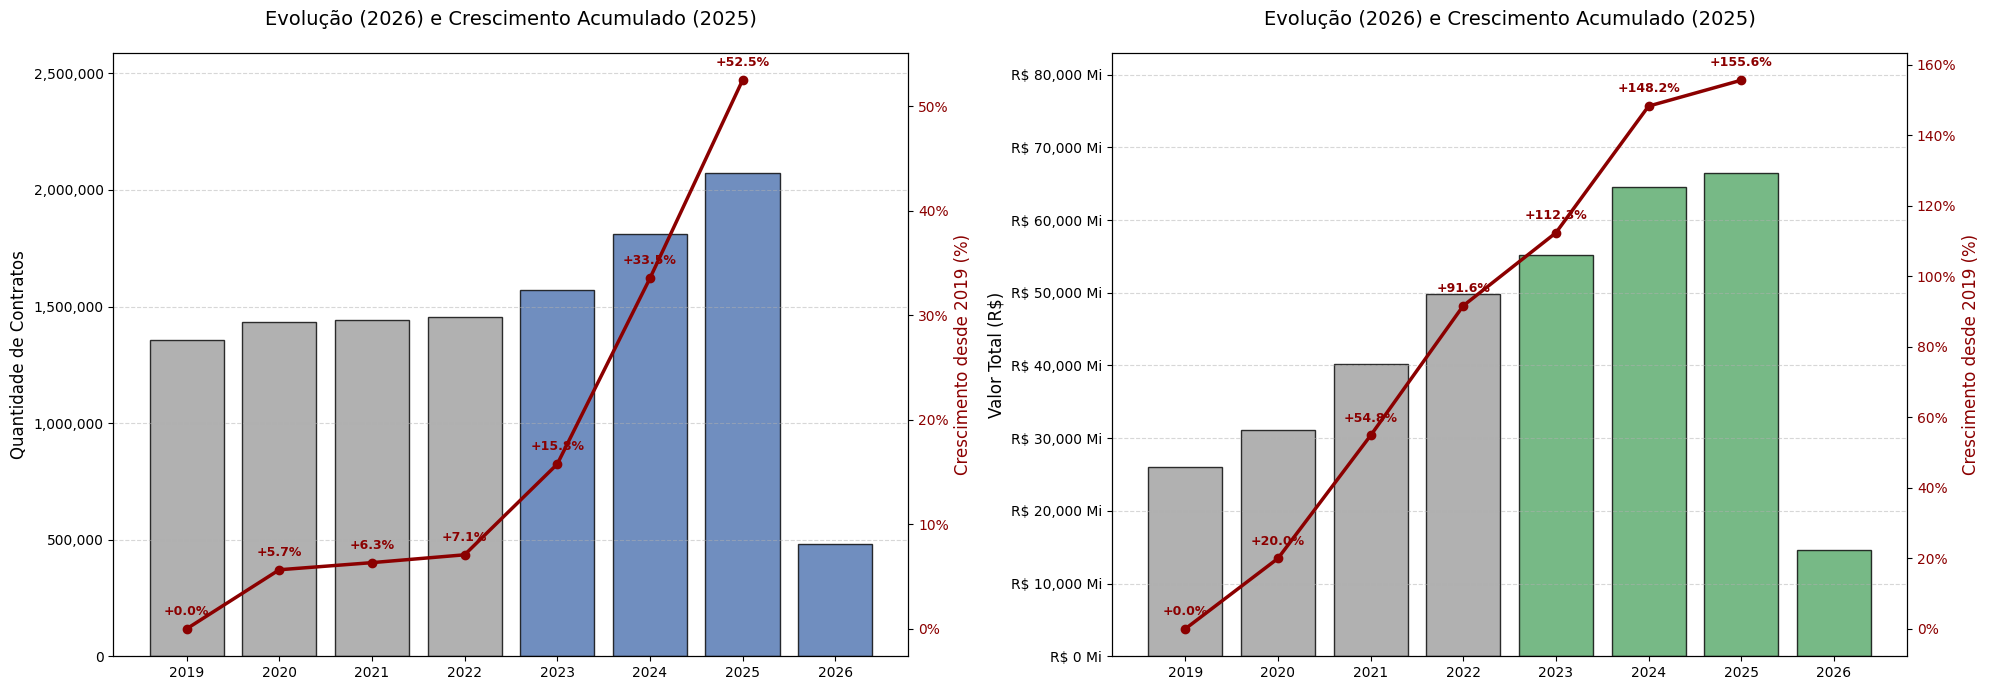

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# 1. Garantir colunas de Totais Globais e Filtro (2019-2026)
df_pronaf_consolidado['ANO_num'] = pd.to_numeric(df_pronaf_consolidado['ANO'], errors='coerce')

# Filtro expandido até 2026
df_filtrado_plot = df_pronaf_consolidado[
    (df_pronaf_consolidado['ANO_num'] >= 2019) &
    (df_pronaf_consolidado['ANO_num'] <= 2026)
].copy()

# 2. Agrupar os dados por Ano
df_evolucao_plot = df_filtrado_plot.groupby('ANO_num')[['qtd_contratos_total', 'valor_contratos_total']].sum().reset_index()
df_evolucao_plot['ANO_num'] = df_evolucao_plot['ANO_num'].astype(int)
df_evolucao_plot = df_evolucao_plot.sort_values('ANO_num')

# 3. Calcular a Variação Acumulada (Base 2019)
base_qtd = df_evolucao_plot.loc[df_evolucao_plot['ANO_num'] == 2019, 'qtd_contratos_total'].values[0]
base_valor = df_evolucao_plot.loc[df_evolucao_plot['ANO_num'] == 2019, 'valor_contratos_total'].values[0]

df_evolucao_plot['var_acum_qtd'] = ((df_evolucao_plot['qtd_contratos_total'] / base_qtd) - 1) * 100
df_evolucao_plot['var_acum_valor'] = ((df_evolucao_plot['valor_contratos_total'] / base_valor) - 1) * 100

# Criar dataframe específico para as linhas (apenas até 2025)
df_linhas = df_evolucao_plot[df_evolucao_plot['ANO_num'] <= 2025].copy()

# 4. Definir cores condicionais (Cinza para 2019-2022)
cores_qtd = ['#9E9E9E' if ano <= 2022 else '#4C72B0' for ano in df_evolucao_plot['ANO_num']]
cores_valor = ['#9E9E9E' if ano <= 2022 else '#55A868' for ano in df_evolucao_plot['ANO_num']]

# 5. Desenhar os Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

## --- Gráfico 1: Quantidade de Contratos (Barra até 2026) + Variação (Linha até 2025) ---
barras_qtd = ax1.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot['qtd_contratos_total'], color=cores_qtd, alpha=0.8, edgecolor='black', label='Qtd. Contratos')
ax1.set_title('Evolução (2026) e Crescimento Acumulado (2025)', fontsize=14, pad=20)
ax1.set_ylabel('Quantidade de Contratos', fontsize=12)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax1_twin = ax1.twinx()
linha_qtd = ax1_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas['var_acum_qtd'], color='darkred', marker='o', linewidth=2.5, label='Var. Acumulada (%)')
ax1_twin.set_ylabel('Crescimento desde 2019 (%)', color='darkred', fontsize=12)
ax1_twin.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax1_twin.tick_params(axis='y', labelcolor='darkred')

for x, y in zip(df_linhas['ANO_num'].astype(str), df_linhas['var_acum_qtd']):
    ax1_twin.annotate(f'{y:+.1f}%', xy=(x, y), xytext=(0, 10), textcoords="offset points", ha='center', fontsize=9, fontweight='bold', color='darkred')

## --- Gráfico 2: Valor Total (Barra até 2026) + Variação (Linha até 2025) ---
barras_valor = ax2.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot['valor_contratos_total'], color=cores_valor, alpha=0.8, edgecolor='black', label='Valor Total')
ax2.set_title('Evolução (2026) e Crescimento Acumulado (2025)', fontsize=14, pad=20)
ax2.set_ylabel('Valor Total (R$)', fontsize=12)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x/1e6:,.0f} Mi'))
ax2.grid(axis='y', linestyle='--', alpha=0.5)

ax2_twin = ax2.twinx()
linha_valor = ax2_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas['var_acum_valor'], color='darkred', marker='o', linewidth=2.5, label='Var. Acumulada (%)')
ax2_twin.set_ylabel('Crescimento desde 2019 (%)', color='darkred', fontsize=12)
ax2_twin.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
ax2_twin.tick_params(axis='y', labelcolor='darkred')

for x, y in zip(df_linhas['ANO_num'].astype(str), df_linhas['var_acum_valor']):
    ax2_twin.annotate(f'{y:+.1f}%', xy=(x, y), xytext=(0, 10), textcoords="offset points", ha='center', fontsize=9, fontweight='bold', color='darkred')

ax1.set_ylim(0, df_evolucao_plot['qtd_contratos_total'].max() * 1.25)
ax2.set_ylim(0, df_evolucao_plot['valor_contratos_total'].max() * 1.25)

plt.tight_layout()
plt.show()

In [43]:
import pandas as pd

# 1. Definir os anos de comparação
ano_base = 2023
ano_final = 2025

# 2. Agrupar os dados por Município, UF e Ano (Agora incluindo Valores e Quantidades)
df_mun = df_pronaf_consolidado.groupby(['nome_municipio', 'uf', 'ANO_num'])[['valor_contratos_total', 'qtd_contratos_total']].sum().reset_index()

# 3. Filtrar apenas os dois anos que queremos comparar
df_mun_comp = df_mun[df_mun['ANO_num'].isin([ano_base, ano_final])]

# 4. Pivotar a tabela (transformar os anos em colunas para as duas métricas)
df_pivot = df_mun_comp.pivot_table(
    index=['nome_municipio', 'uf'],
    columns='ANO_num',
    values=['valor_contratos_total', 'qtd_contratos_total'],
    fill_value=0
)

# Como o pivot criou um "MultiIndex" (Ex: valor_contratos_total -> 2019), vamos juntar os nomes
df_pivot.columns = [f'{metrica}_{ano}' for metrica, ano in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# Definir as colunas geradas dinamicamente
col_valor_base = f'valor_contratos_total_{ano_base}'
col_valor_final = f'valor_contratos_total_{ano_final}'
col_qtd_base = f'qtd_contratos_total_{ano_base}'
col_qtd_final = f'qtd_contratos_total_{ano_final}'

# 5. Aplicar filtros de consistência para evitar variações irrealistas em municípios muito pequenos
df_pivot = df_pivot[df_pivot[col_valor_base] >= 100000].copy() # Mínimo R$ 100 mil no ano base
df_pivot = df_pivot[df_pivot[col_qtd_base] >= 5].copy()      # Mínimo de 5 contratos no ano base

# 6. Calcular a variação percentual para ambas as métricas
df_pivot['var_pct_valor'] = ((df_pivot[col_valor_final] / df_pivot[col_valor_base]) - 1) * 100
df_pivot['var_pct_qtd'] = ((df_pivot[col_qtd_final] / df_pivot[col_qtd_base]) - 1) * 100

# 7. Separar os 3 Maiores e 3 Menores (ordenados pela variação de Valor)
top_3_maiores = df_pivot.sort_values(by='var_pct_valor', ascending=False).head(3)
top_3_menores = df_pivot.sort_values(by='var_pct_valor', ascending=True).head(3)

# 8. Imprimir o relatório completo
print(f"🏆 TOP 3 MUNICÍPIOS COM MAIOR CRESCIMENTO ({ano_base} vs {ano_final})")
print("=" * 85)
for i, row in top_3_maiores.iterrows():
    print(f"📍 {row['nome_municipio']} ({row['uf']})")
    print(f"   💰 VALOR DOS CONTRATOS: Variação de {row['var_pct_valor']:+.1f}%")
    print(f"      • {ano_base}: R$ {row[col_valor_base]:,.2f}  |  {ano_final}: R$ {row[col_valor_final]:,.2f}")
    print(f"   📄 NÚMERO DE CONTRATOS: Variação de {row['var_pct_qtd']:+.1f}%")
    print(f"      • {ano_base}: {int(row[col_qtd_base])} contratos  |  {ano_final}: {int(row[col_qtd_final])} contratos\n")

print(f"📉 TOP 3 MUNICÍPIOS COM MAIOR QUEDA ({ano_base} vs {ano_final})")
print("=" * 85)
for i, row in top_3_menores.iterrows():
    print(f"📍 {row['nome_municipio']} ({row['uf']})")
    print(f"   📉 VALOR DOS CONTRATOS: Variação de {row['var_pct_valor']:+.1f}%")
    print(f"      • {ano_base}: R$ {row[col_valor_base]:,.2f}  |  {ano_final}: R$ {row[col_valor_final]:,.2f}")
    print(f"   📄 NÚMERO DE CONTRATOS: Variação de {row['var_pct_qtd']:+.1f}%")
    print(f"      • {ano_base}: {int(row[col_qtd_base])} contratos  |  {ano_final}: {int(row[col_qtd_final])} contratos\n")

🏆 TOP 3 MUNICÍPIOS COM MAIOR CRESCIMENTO (2023 vs 2025)
📍 Mocajuba (PA)
   💰 VALOR DOS CONTRATOS: Variação de +5878.7%
      • 2023: R$ 111,767.00  |  2025: R$ 6,682,257.56
   📄 NÚMERO DE CONTRATOS: Variação de +4680.0%
      • 2023: 5 contratos  |  2025: 239 contratos

📍 São Sebastião da Boa Vista (PA)
   💰 VALOR DOS CONTRATOS: Variação de +3317.2%
      • 2023: R$ 607,563.00  |  2025: R$ 20,761,924.68
   📄 NÚMERO DE CONTRATOS: Variação de +1885.2%
      • 2023: 54 contratos  |  2025: 1072 contratos

📍 Cametá (PA)
   💰 VALOR DOS CONTRATOS: Variação de +3170.7%
      • 2023: R$ 2,434,504.38  |  2025: R$ 79,624,284.04
   📄 NÚMERO DE CONTRATOS: Variação de +4364.1%
      • 2023: 92 contratos  |  2025: 4107 contratos

📉 TOP 3 MUNICÍPIOS COM MAIOR QUEDA (2023 vs 2025)
📍 Bertioga (SP)
   📉 VALOR DOS CONTRATOS: Variação de -100.0%
      • 2023: R$ 198,744.00  |  2025: R$ 0.00
   📄 NÚMERO DE CONTRATOS: Variação de -100.0%
      • 2023: 6 contratos  |  2025: 0 contratos

📍 Saltinho (SP)
   📉 V

Gráfico por publico

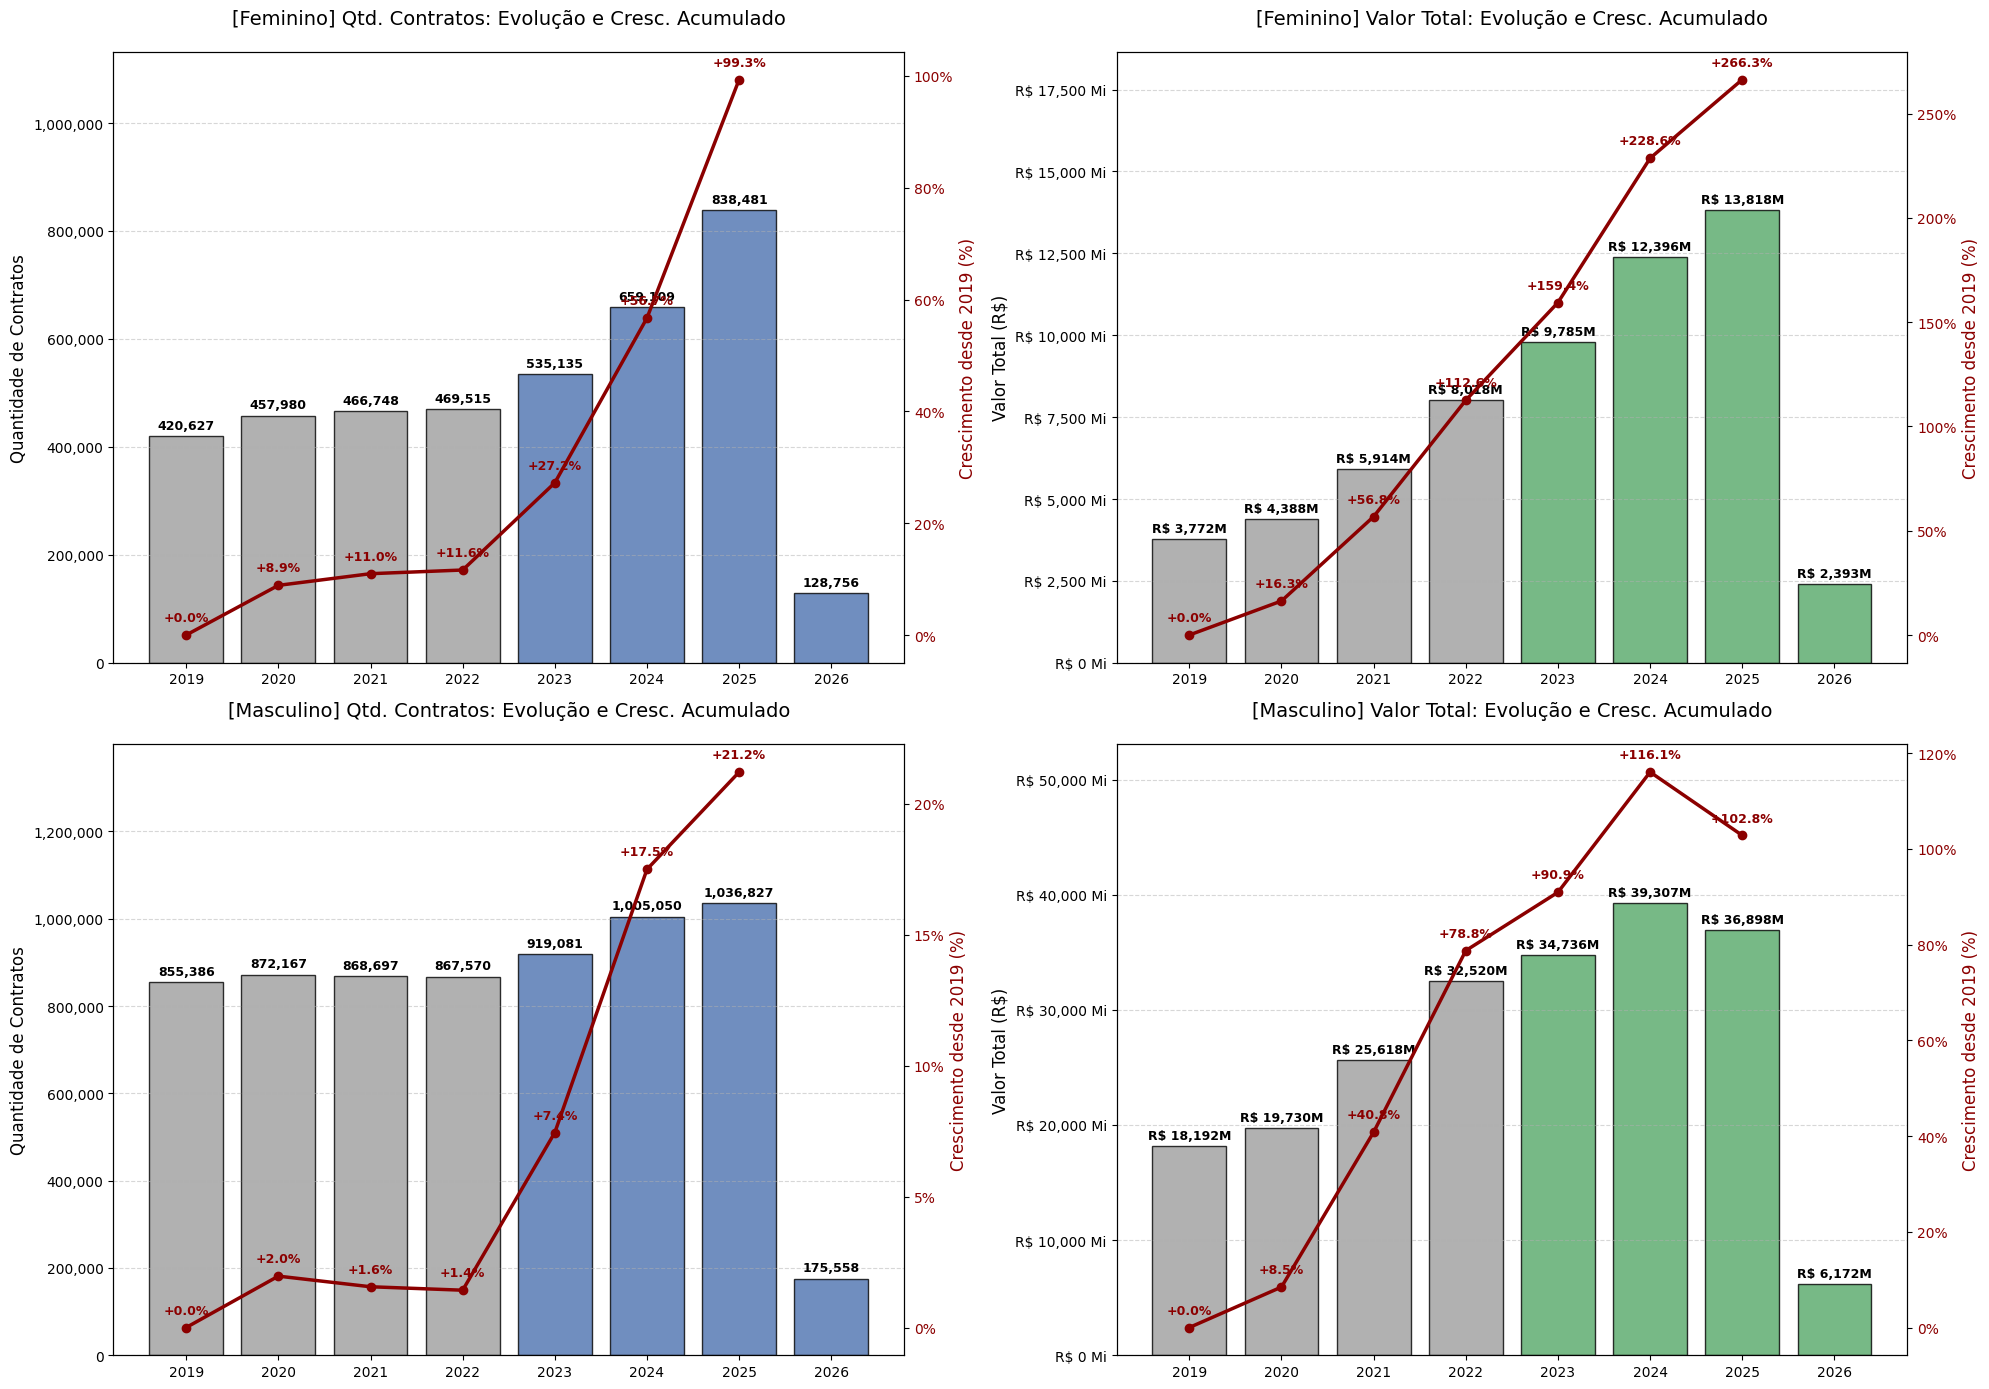

In [45]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

# 1. Garantir a coluna de Ano e Filtro (2019-2026)
df_pronaf_consolidado['ANO_num'] = pd.to_numeric(df_pronaf_consolidado['ANO'], errors='coerce')

df_filtrado_plot = df_pronaf_consolidado[
    (df_pronaf_consolidado['ANO_num'] >= 2019) &
    (df_pronaf_consolidado['ANO_num'] <= 2026)
].copy()

# 2. Definir as colunas específicas de gênero que queremos agrupar
colunas_analise = [
    'qtd_contratos_anual_Feminino', 'valor_total_contratos_anual_Feminino',
    'qtd_contratos_anual_Masculino', 'valor_total_contratos_anual_Masculino'
]

# Agrupar os dados por Ano
df_evolucao_plot = df_filtrado_plot.groupby('ANO_num')[colunas_analise].sum().reset_index()
df_evolucao_plot['ANO_num'] = df_evolucao_plot['ANO_num'].astype(int)
df_evolucao_plot = df_evolucao_plot.sort_values('ANO_num')

# 3. Calcular a Variação Acumulada (Base 2019) para cada uma das 4 colunas
for col in colunas_analise:
    base_val = df_evolucao_plot.loc[df_evolucao_plot['ANO_num'] == 2019, col].values[0]
    base_val = base_val if base_val != 0 else 1
    df_evolucao_plot[f'var_acum_{col}'] = ((df_evolucao_plot[col] / base_val) - 1) * 100

# Criar dataframe específico para as linhas (apenas até 2025)
df_linhas = df_evolucao_plot[df_evolucao_plot['ANO_num'] <= 2025].copy()

# 4. Definir cores condicionais (Cinza para 2019-2022)
cores_qtd = ['#9E9E9E' if ano <= 2022 else '#4C72B0' for ano in df_evolucao_plot['ANO_num']]
cores_valor = ['#9E9E9E' if ano <= 2022 else '#55A868' for ano in df_evolucao_plot['ANO_num']]

# 5. Desenhar os Gráficos (Criamos um grid 2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

configuracoes_genero = [
    ('Feminino', 'qtd_contratos_anual_Feminino', 'valor_total_contratos_anual_Feminino', axes[0, 0], axes[0, 1]),
    ('Masculino', 'qtd_contratos_anual_Masculino', 'valor_total_contratos_anual_Masculino', axes[1, 0], axes[1, 1])
]

for titulo_genero, col_qtd, col_valor, ax1, ax2 in configuracoes_genero:

    ## --- Gráfico Quantidade de Contratos ---
    barras_qtd = ax1.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot[col_qtd], color=cores_qtd, alpha=0.8, edgecolor='black')
    ax1.set_title(f'[{titulo_genero}] Qtd. Contratos: Evolução e Cresc. Acumulado', fontsize=14, pad=20)
    ax1.set_ylabel('Quantidade de Contratos', fontsize=12)
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    # Rótulos nas barras de Quantidade
    for barra in barras_qtd:
        altura = barra.get_height()
        ax1.annotate(f'{int(altura):,}', xy=(barra.get_x() + barra.get_width() / 2, altura), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax1_twin = ax1.twinx()
    ax1_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas[f'var_acum_{col_qtd}'], color='darkred', marker='o', linewidth=2.5)
    ax1_twin.set_ylabel('Crescimento desde 2019 (%)', color='darkred', fontsize=12)
    ax1_twin.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
    ax1_twin.tick_params(axis='y', labelcolor='darkred')

    for x, y in zip(df_linhas['ANO_num'].astype(str), df_linhas[f'var_acum_{col_qtd}']):
        ax1_twin.annotate(f'{y:+.1f}%', xy=(x, y), xytext=(0, 10), textcoords="offset points", ha='center', fontsize=9, fontweight='bold', color='darkred')

    ## --- Gráfico Valor Total ---
    barras_valor = ax2.bar(df_evolucao_plot['ANO_num'].astype(str), df_evolucao_plot[col_valor], color=cores_valor, alpha=0.8, edgecolor='black')
    ax2.set_title(f'[{titulo_genero}] Valor Total: Evolução e Cresc. Acumulado', fontsize=14, pad=20)
    ax2.set_ylabel('Valor Total (R$)', fontsize=12)
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'R$ {x/1e6:,.0f} Mi'))
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Rótulos nas barras de Valor
    for barra in barras_valor:
        altura = barra.get_height()
        rotulo = f'R$ {altura/1e6:,.0f}M' if altura >= 1e6 else f'R$ {altura/1e3:,.0f}k'
        ax2.annotate(rotulo, xy=(barra.get_x() + barra.get_width() / 2, altura), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2_twin = ax2.twinx()
    ax2_twin.plot(df_linhas['ANO_num'].astype(str), df_linhas[f'var_acum_{col_valor}'], color='darkred', marker='o', linewidth=2.5)
    ax2_twin.set_ylabel('Crescimento desde 2019 (%)', color='darkred', fontsize=12)
    ax2_twin.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
    ax2_twin.tick_params(axis='y', labelcolor='darkred')

    for x, y in zip(df_linhas['ANO_num'].astype(str), df_linhas[f'var_acum_{col_valor}']):
        ax2_twin.annotate(f'{y:+.1f}%', xy=(x, y), xytext=(0, 10), textcoords="offset points", ha='center', fontsize=9, fontweight='bold', color='darkred')

    ax1.set_ylim(0, df_evolucao_plot[col_qtd].max() * 1.35)
    ax2.set_ylim(0, df_evolucao_plot[col_valor].max() * 1.35)

plt.tight_layout()
plt.show()

Proposta de Texto

In [54]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.9 MB/s eta 0:00:00


In [57]:
import os
import matplotlib.pyplot as plt
from docx import Document
from docx.shared import Pt, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml.ns import qn
import numpy as np

def set_font_style(paragraph, font_name='Arial', font_size=11, bold=False):
    for run in paragraph.runs:
        run.font.name = font_name
        run.font.size = Pt(font_size)
        run.bold = bold
        run._element.rPr.rFonts.set(qn('w:eastAsia'), font_name)

def format_paragraph(paragraph, line_spacing=1.5, space_after=10):
    paragraph.paragraph_format.line_spacing = line_spacing
    paragraph.paragraph_format.space_after = Pt(space_after)

def formata_v(valor):
    v = valor.item() if hasattr(valor, 'item') else valor
    return f'{v:,.0f}'.replace(',', '.')

def formata_r(valor):
    v = valor.item() if hasattr(valor, 'item') else valor
    return f'R$ {v:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

def calc_pct(parte, total):
    p = parte.item() if hasattr(parte, 'item') else parte
    t = total.item() if hasattr(total, 'item') else total
    return f'{(p/t*100):.1f}%'.replace('.', ',') if t > 0 else '0,0%'

def add_detailed_table(doc, label, v_uf, v_br, uf_label):
    table = doc.add_table(rows=1, cols=4)
    table.style = 'Table Grid'
    hdr = table.rows[0].cells
    hdr[0].text = str(label)
    hdr[1].text = str(uf_label)
    hdr[2].text = 'Brasil'
    hdr[3].text = '% Part.'
    for cell in hdr:
        for p in cell.paragraphs:
            set_font_style(p, font_size=11, bold=True)
    row = table.add_row().cells
    row[0].text = 'Total'
    row[1].text = str(formata_v(v_uf) if 'valor' not in str(label).lower() else formata_r(v_uf))
    row[2].text = str(formata_v(v_br) if 'valor' not in str(label).lower() else formata_r(v_br))
    row[3].text = str(calc_pct(v_uf, v_br))
    for cell in row:
        for p in cell.paragraphs:
            set_font_style(p, font_size=11)

# --- Totais Brasil ---
br_pronaf_v_total = df_pronaf_consolidado['valor_contratos_total'].sum()
br_pronaf_q_total = df_pronaf_consolidado['qtd_contratos_total'].sum()
br_pronaf_v_fem = df_pronaf_consolidado['valor_total_contratos_anual_Feminino'].sum()
br_pronaf_v_masc = df_pronaf_consolidado['valor_total_contratos_anual_Masculino'].sum()

# Definimos uma UF para o exemplo ou fazemos para todas as UFs
uf_alvo = 'TO'

# 1. Salvar gráficos temporariamente para o Word
fig.savefig('temp_evolucao.png', dpi=100)

# 2. Criar Documento
doc = Document()
h = doc.add_heading(f'Relatório Consolidado PRONAF - {uf_alvo}', level=0)
h.alignment = WD_ALIGN_PARAGRAPH.CENTER
set_font_style(h, font_size=16, bold=True)

doc.add_heading('Sumário Executivo', level=1)
df_uf = df_pronaf_consolidado[df_pronaf_consolidado['uf'] == uf_alvo]
val_total_uf = df_uf['valor_contratos_total'].sum()
qtd_total_uf = df_uf['qtd_contratos_total'].sum()

p = doc.add_paragraph(f"O estado de {uf_alvo} registrou R$ {formata_r(val_total_uf)} em contratos, representando {calc_pct(val_total_uf, br_pronaf_v_total)} do total nacional.")
set_font_style(p)

# 3. Adicionar Gráficos
doc.add_heading('Evolução Histórica e Variação Acumulada', level=1)
doc.add_picture('temp_evolucao.png', width=Inches(6))

# 4. Adicionar Tabelas de Gênero
doc.add_heading('Distribuição por Gênero', level=1)
items = [
    ('Qtd Contratos Feminino', df_uf['qtd_contratos_anual_Feminino'].sum(), df_pronaf_consolidado['qtd_contratos_anual_Feminino'].sum()),
    ('Qtd Contratos Masculino', df_uf['qtd_contratos_anual_Masculino'].sum(), df_pronaf_consolidado['qtd_contratos_anual_Masculino'].sum()),
    ('Qtd Total Consolidada', qtd_total_uf, br_pronaf_q_total)
]
for label, v_uf, v_br in items:
    add_detailed_table(doc, label, v_uf, v_br, uf_alvo)

# 5. Adicionar Rankings de Municípios (Top 3 Maiores e Menores)
doc.add_heading('Destaques Municipais (Variação de Valor 2023-2025)', level=1)

doc.add_heading('Top 3 - Maiores Crescimentos', level=2)
for _, row in top_3_maiores.iterrows():
    p = doc.add_paragraph(f"📍 {row['nome_municipio']}: {row['var_pct_valor']:+.1f}% (Valor) | {row['var_pct_qtd']:+.1f}% (Qtd)")
    set_font_style(p)

doc.add_heading('Top 3 - Maiores Quedas', level=2)
for _, row in top_3_menores.iterrows():
    p = doc.add_paragraph(f"📍 {row['nome_municipio']}: {row['var_pct_valor']:+.1f}% (Valor) | {row['var_pct_qtd']:+.1f}% (Qtd)")
    set_font_style(p)

# Salvar
caminho_arquivo = os.path.join(OUTPUT_DIR, f'Relatorio_PRONAF_{uf_alvo}.docx')
doc.save(caminho_arquivo)
print(f'Documento Word gerado em: {caminho_arquivo}')

Documento Word gerado em: /content/drive/MyDrive/DAMEI_Relatorio_Dados/dados_brutos/saida_teste/Relatorio_PRONAF_TO.docx


In [53]:
## 1. Instalar a biblioteca do Gemini
!pip install -q -U google-generativeai

import google.generativeai as genai
from google.colab import userdata

# 2. Configurar a IA
GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

# 3. Preparar os dados
dados_em_texto = top_3_maiores.to_markdown(index=False)

# 4. Prompt
prompt = f"""
Você é um analista de dados sênior auxiliando um gestor público.
Analise a seguinte tabela que mostra os 3 municípios com maior crescimento financeiro nos contratos do PRONAF entre 2019 e 2026:

{dados_em_texto}

Por favor, escreva um insight executivo de no máximo 2 parágrafos.
Destaque o município com o desempenho mais impressionante e sugira brevemente o que esse crescimento pode significar para a economia local.
Seja direto, profissional e não use jargões complexos.
"""

# 5. Chamar a IA (Atualizado para gemini-2.0-flash com base nos modelos disponíveis)
try:
    model = genai.GenerativeModel('gemini-2.0-flash')
    resposta = model.generate_content(prompt)
    print("\n💡 INSIGHT GERADO PELA IA:")
    print("=" * 80)
    print(resposta.text)
except Exception as e:
    print(f"\nFalha ao chamar o modelo: {e}")


Falha ao chamar o modelo: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash
Please retry in 16.043533672s.
